# Metadata-Based ADHD and Sex Prediction using Machine Learning

## Overview
This notebook investigates whether demographic, behavioural and MRI metadata can predict:

- ADHD diagnosis
- Biological sex

using two complementary modelling approaches:

- LightGBM for predictive modelling
- Logistic Regression for statistical inference

Model interpretation was performed using SHAP values, while model assumptions were assessed using Box–Tidwell tests and Variance Inflation Factors (VIF).m

In [ ]:
# STEP 1: LOAD AND ORGANIZE DATA

import pandas as pd
import numpy as np

# 1. Load datasets

folder = r"YOUR_FOLDER_PATH"

cat = pd.read_excel(r"C:\Users\Romi\Desktop\WiDS Datathon\data\TRAIN_NEW\TRAIN_CATEGORICAL_METADATA_new.xlsx")
quant = pd.read_excel(r"C:\Users\Romi\Desktop\WiDS Datathon\data\TRAIN_NEW\TRAIN_QUANTITATIVE_METADATA_new.xlsx")
target = pd.read_excel(r"C:\Users\Romi\Desktop\WiDS Datathon\data\TRAIN_NEW\TRAINING_SOLUTIONS.xlsx")

print("Categorical:", cat.shape)
print("Quantitative:", quant.shape)
print("Target:", target.shape)


# 2. Merge datasets

metadata = pd.merge(cat, quant, on="participant_id")
metadata = pd.merge(metadata, target, on="participant_id")

print("\nMerged dataset:", metadata.shape)


# 3. Define numerical predictors
# Barratt variables are treated as ordered numerical scores.

numerical_cols = [
    "EHQ_EHQ_Total",
    "ColorVision_CV_Score",

    "APQ_P_APQ_P_CP",
    "APQ_P_APQ_P_ID",
    "APQ_P_APQ_P_INV",
    "APQ_P_APQ_P_OPD",
    "APQ_P_APQ_P_PM",
    "APQ_P_APQ_P_PP",

    "SDQ_SDQ_Conduct_Problems",
    "SDQ_SDQ_Emotional_Problems",
    "SDQ_SDQ_Generating_Impact",
    "SDQ_SDQ_Hyperactivity",
    "SDQ_SDQ_Peer_Problems",
    "SDQ_SDQ_Prosocial",

    "MRI_Track_Age_at_Scan",

    # Ordered Barratt scores
    "Barratt_Barratt_P1_Edu",
    "Barratt_Barratt_P1_Occ",
    "Barratt_Barratt_P2_Edu",
    "Barratt_Barratt_P2_Occ"
]


# 4. Define nominal categorical predictors

categorical_cols = [
    "Basic_Demos_Enroll_Year",
    "Basic_Demos_Study_Site",
    "PreInt_Demos_Fam_Child_Ethnicity",
    "PreInt_Demos_Fam_Child_Race",
    "MRI_Track_Scan_Location"
]


# 5. Create predictor and target datasets

X = metadata[numerical_cols + categorical_cols].copy()

y_adhd = metadata["ADHD_Outcome"].astype(int)
y_sex = metadata["Sex_F"].astype(int)


# 6. Basic checks

print("\nX shape:", X.shape)
print("Numerical variables:", len(numerical_cols))
print("Categorical variables:", len(categorical_cols))

print("\nADHD distribution:")
print(y_adhd.value_counts())

print("\nSex distribution:")
print(y_sex.value_counts())


# 7. Missing-value summary

missing = pd.DataFrame({
    "Missing_N": X.isna().sum(),
    "Missing_Percent": X.isna().mean() * 100
})

missing = missing[missing["Missing_N"] > 0].sort_values(
    "Missing_Percent",
    ascending=False
)

display(missing)

Categorical: (1213, 10)
Quantitative: (1213, 19)
Target: (1213, 3)

Merged dataset: (1213, 30)

X shape: (1213, 24)
Numerical variables: 19
Categorical variables: 5

ADHD distribution:
ADHD_Outcome
1    831
0    382
Name: count, dtype: int64

Sex distribution:
Sex_F
0    797
1    416
Name: count, dtype: int64


,Missing_N,Missing_Percent
MRI_Track_Age_at_Scan,360,29.678483
Barratt_Barratt_P2_Occ,222,18.301731
Barratt_Barratt_P2_Edu,198,16.323166
PreInt_Demos_Fam_Child_Race,54,4.451772
PreInt_Demos_Fam_Child_Ethnicity,43,3.544930
Barratt_Barratt_P1_Occ,31,2.555647
ColorVision_CV_Score,23,1.896125
Barratt_Barratt_P1_Edu,15,1.236603
EHQ_EHQ_Total,13,1.071723
APQ_P_APQ_P_CP,12,0.989283


In [ ]:
# STEP 2: CHECK CATEGORICAL LEVEL FREQUENCIES

for col in categorical_cols:
    
    counts = X[col].value_counts(dropna=False).sort_index()
    percentages = X[col].value_counts(
        dropna=False,
        normalize=True
    ).sort_index() * 100

    summary = pd.DataFrame({
        "N": counts,
        "Percent": percentages
    })

    print("\n" + "=" * 65)
    print(col)
    print("=" * 65)

    display(summary.round(2))


Basic_Demos_Enroll_Year


,N,Percent
Basic_Demos_Enroll_Year,,
2015,36,2.97
2016,191,15.75
2017,254,20.94
2018,415,34.21
2019,312,25.72
2020,5,0.41



Basic_Demos_Study_Site


,N,Percent
Basic_Demos_Study_Site,,
1,652,53.75
2,11,0.91
3,430,35.45
4,120,9.89



PreInt_Demos_Fam_Child_Ethnicity


,N,Percent
PreInt_Demos_Fam_Child_Ethnicity,,
0.0,777,64.06
1.0,296,24.40
2.0,77,6.35
3.0,20,1.65
NaN,43,3.54



PreInt_Demos_Fam_Child_Race


,N,Percent
PreInt_Demos_Fam_Child_Race,,
0.0,573,47.24
1.0,181,14.92
2.0,128,10.55
3.0,30,2.47
4.0,10,0.82
7.0,2,0.16
8.0,195,16.08
9.0,23,1.90
10.0,11,0.91



MRI_Track_Scan_Location


,N,Percent
MRI_Track_Scan_Location,,
1.0,179,14.76
2.0,532,43.86
3.0,463,38.17
4.0,36,2.97
NaN,3,0.25


In [ ]:
# STEP 3: MERGE RARE CATEGORICAL LEVELS

X_clean = X.copy()


# 1. Enrollment year
# Merge 2020 into 2019 because only 5 participants are from 2020

X_clean["Basic_Demos_Enroll_Year"] = (
    X_clean["Basic_Demos_Enroll_Year"]
    .replace({2020: 2019})
)


# 2. Race
# Combine very rare race categories into a common "Other" level

rare_race = [4.0, 7.0, 10.0, 11.0]

X_clean["PreInt_Demos_Fam_Child_Race"] = (
    X_clean["PreInt_Demos_Fam_Child_Race"]
    .replace(rare_race, 99.0)
)

# 99 = Other / pooled rare categories


# 3. Verify categorical distributions after merging

for col in categorical_cols:

    counts = X_clean[col].value_counts(dropna=False).sort_index()

    percentages = (
        X_clean[col]
        .value_counts(dropna=False, normalize=True)
        .sort_index() * 100
    )

    summary = pd.DataFrame({
        "N": counts,
        "Percent": percentages
    })

    print("\n" + "=" * 65)
    print(col)
    print("=" * 65)

    display(summary.round(2))


Basic_Demos_Enroll_Year


,N,Percent
Basic_Demos_Enroll_Year,,
2015,36,2.97
2016,191,15.75
2017,254,20.94
2018,415,34.21
2019,317,26.13



Basic_Demos_Study_Site


,N,Percent
Basic_Demos_Study_Site,,
1,652,53.75
2,11,0.91
3,430,35.45
4,120,9.89



PreInt_Demos_Fam_Child_Ethnicity


,N,Percent
PreInt_Demos_Fam_Child_Ethnicity,,
0.0,777,64.06
1.0,296,24.40
2.0,77,6.35
3.0,20,1.65
NaN,43,3.54



PreInt_Demos_Fam_Child_Race


,N,Percent
PreInt_Demos_Fam_Child_Race,,
0.0,573,47.24
1.0,181,14.92
2.0,128,10.55
3.0,30,2.47
8.0,195,16.08
9.0,23,1.90
99.0,29,2.39
NaN,54,4.45



MRI_Track_Scan_Location


,N,Percent
MRI_Track_Scan_Location,,
1.0,179,14.76
2.0,532,43.86
3.0,463,38.17
4.0,36,2.97
NaN,3,0.25


In [ ]:
# DEFINE NUMERICAL AND CATEGORICAL VARIABLES

# Barratt variables are treated as numerical/ordinal
num_vars = [
    'EHQ_EHQ_Total',
    'ColorVision_CV_Score',

    'APQ_P_APQ_P_CP',
    'APQ_P_APQ_P_ID',
    'APQ_P_APQ_P_INV',
    'APQ_P_APQ_P_OPD',
    'APQ_P_APQ_P_PM',
    'APQ_P_APQ_P_PP',

    'SDQ_SDQ_Conduct_Problems',
    'SDQ_SDQ_Emotional_Problems',
    'SDQ_SDQ_Generating_Impact',
    'SDQ_SDQ_Hyperactivity',
    'SDQ_SDQ_Peer_Problems',
    'SDQ_SDQ_Prosocial',

    'MRI_Track_Age_at_Scan',

    'Barratt_Barratt_P1_Edu',
    'Barratt_Barratt_P1_Occ',
    'Barratt_Barratt_P2_Edu',
    'Barratt_Barratt_P2_Occ'
]

cat_vars = [
    'Basic_Demos_Enroll_Year',
    'Basic_Demos_Study_Site',
    'PreInt_Demos_Fam_Child_Ethnicity',
    'PreInt_Demos_Fam_Child_Race',
    'MRI_Track_Scan_Location'
]

print("Numerical variables:", len(num_vars))
print("Categorical variables:", len(cat_vars))
print("Total:", len(num_vars) + len(cat_vars))

Numerical variables: 19
Categorical variables: 5
Total: 24


In [ ]:
# STEP 4: IMPUTATION + ENCODING
# Start explicitly from X_clean

import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer


# 1. START FROM THE RARE-CATEGORY-MERGED DATA

X_imp = X_clean.copy()

# Quick confirmation BEFORE imputation
print("2020 count before imputation:",
      (X_imp["Basic_Demos_Enroll_Year"] == 2020).sum())

print("Race levels before imputation:",
      sorted(X_imp["PreInt_Demos_Fam_Child_Race"].dropna().unique()))


# 2. IMPUTE NUMERICAL VARIABLES

num_imputer = IterativeImputer(
    max_iter=20,
    random_state=42,
    initial_strategy="median"
)

X_imp[num_vars] = num_imputer.fit_transform(
    X_imp[num_vars]
)


# 3. IMPUTE CATEGORICAL VARIABLES

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_imp[cat_vars] = cat_imputer.fit_transform(
    X_imp[cat_vars]
)


# 4. EXPLICITLY CONVERT CATEGORICAL VARIABLES TO STRINGS

X_cat = X_imp[cat_vars].astype(str)


# 5. ONE-HOT ENCODE

X_cat_encoded = pd.get_dummies(
    X_cat,
    drop_first=True,
    dtype=int
)


# 6. COMBINE NUMERICAL + DUMMIES

X_processed = pd.concat(
    [
        X_imp[num_vars].reset_index(drop=True),
        X_cat_encoded.reset_index(drop=True)
    ],
    axis=1
)

X_processed = X_processed.astype(float)


# 7. FINAL CHECKS

print("\nNumerical predictors:", len(num_vars))
print("Dummy variables:", X_cat_encoded.shape[1])
print("Total predictors:", X_processed.shape[1])

print("\nFinal shape:", X_processed.shape)
print("Missing values:", X_processed.isna().sum().sum())
print("All finite:", np.isfinite(X_processed).all().all())

print("\nEncoded categorical columns:")
print(X_cat_encoded.columns.tolist())

2020 count before imputation: 0
Race levels before imputation: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(8.0), np.float64(9.0), np.float64(99.0)]

Numerical predictors: 19
Dummy variables: 19
Total predictors: 38

Final shape: (1213, 38)
Missing values: 0
All finite: True

Encoded categorical columns:
['Basic_Demos_Enroll_Year_2016.0', 'Basic_Demos_Enroll_Year_2017.0', 'Basic_Demos_Enroll_Year_2018.0', 'Basic_Demos_Enroll_Year_2019.0', 'Basic_Demos_Study_Site_2.0', 'Basic_Demos_Study_Site_3.0', 'Basic_Demos_Study_Site_4.0', 'PreInt_Demos_Fam_Child_Ethnicity_1.0', 'PreInt_Demos_Fam_Child_Ethnicity_2.0', 'PreInt_Demos_Fam_Child_Ethnicity_3.0', 'PreInt_Demos_Fam_Child_Race_1.0', 'PreInt_Demos_Fam_Child_Race_2.0', 'PreInt_Demos_Fam_Child_Race_3.0', 'PreInt_Demos_Fam_Child_Race_8.0', 'PreInt_Demos_Fam_Child_Race_9.0', 'PreInt_Demos_Fam_Child_Race_99.0', 'MRI_Track_Scan_Location_2.0', 'MRI_Track_Scan_Location_3.0', 'MRI_Track_Scan_Location_4.0']


In [ ]:
# STEP 5: ADHD LIGHTGBM — 5-FOLD CROSS-VALIDATION

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import numpy as np


# 1. Data

X_lgbm = X_processed.copy()
y = y_adhd.copy()



# 2. Stratified 5-fold CV


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []


# 3. Train and evaluate each fold


for fold, (train_idx, val_idx) in enumerate(cv.split(X_lgbm, y), 1):

    X_train = X_lgbm.iloc[train_idx]
    X_val = X_lgbm.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC_AUC": roc_auc_score(y_val, y_prob)
    })


# 4. Results


cv_results_adhd = pd.DataFrame(results)

display(cv_results_adhd.round(3))



# 5. Mean + SD


summary_adhd = pd.DataFrame({
    "Mean": cv_results_adhd.drop(columns="Fold").mean(),
    "SD": cv_results_adhd.drop(columns="Fold").std()
})

print("\n5-Fold Cross-Validation Summary:")
display(summary_adhd.round(3))

,Fold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.798,0.739,0.824,0.898,0.860,0.829
1,2,0.790,0.735,0.821,0.886,0.852,0.791
2,3,0.778,0.719,0.811,0.880,0.844,0.790
3,4,0.806,0.769,0.852,0.867,0.860,0.851
4,5,0.756,0.680,0.786,0.886,0.833,0.789



5-Fold Cross-Validation Summary:


,Mean,SD
Accuracy,0.786,0.019
Balanced_Accuracy,0.728,0.033
Precision,0.819,0.024
Recall,0.883,0.011
F1,0.850,0.011
ROC_AUC,0.810,0.028


Confusion Matrix:
[[219 163]
 [ 97 734]]


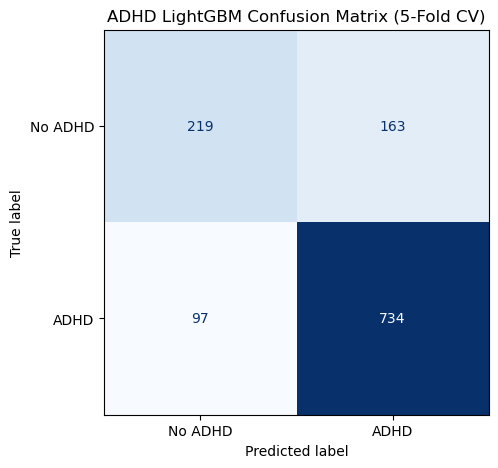

In [ ]:
# STEP 6: ADHD CONFUSION MATRIX


from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Same model used in CV
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

# Cross-validated predictions
y_pred = cross_val_predict(
    estimator=model,
    X=X_lgbm,
    y=y,
    cv=cv,
    method="predict"
)

cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No ADHD", "ADHD"]
)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("ADHD LightGBM Confusion Matrix (5-Fold CV)")
plt.grid(False)
plt.show()

,Feature,Importance
0,SDQ_SDQ_Hyperactivity,7885.385199
1,MRI_Track_Age_at_Scan,2314.431303
2,EHQ_EHQ_Total,1218.096732
3,APQ_P_APQ_P_PM,1072.862886
4,SDQ_SDQ_Generating_Impact,1058.902290
5,APQ_P_APQ_P_INV,1035.053327
6,APQ_P_APQ_P_PP,939.960019
7,Barratt_Barratt_P2_Occ,928.154449
8,APQ_P_APQ_P_OPD,900.498361
9,Barratt_Barratt_P1_Occ,723.730805


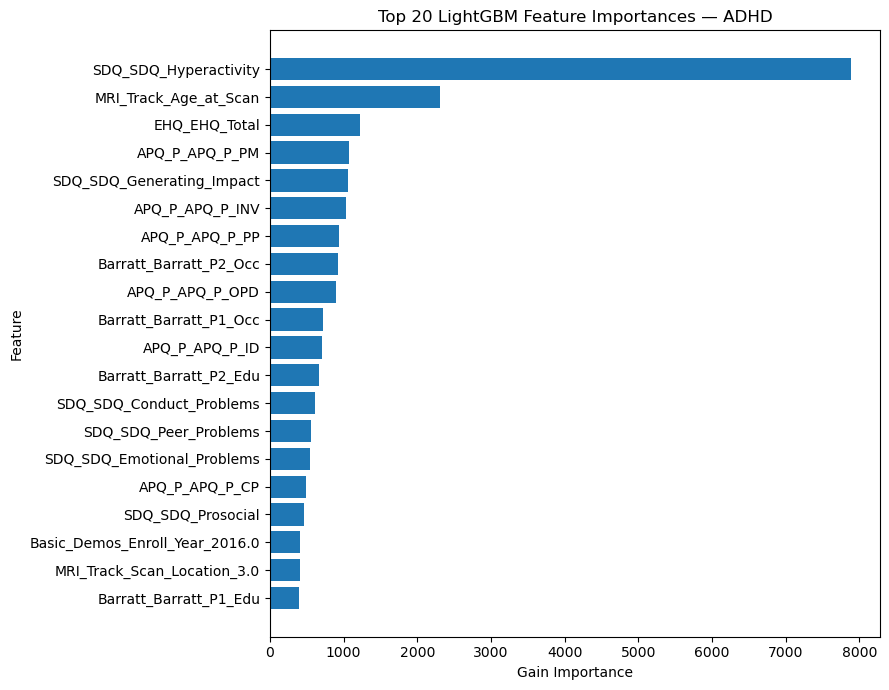

In [ ]:
# STEP 6: FINAL ADHD LIGHTGBM + FEATURE IMPORTANCE


from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Final model
final_lgbm_adhd = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

final_lgbm_adhd.fit(X_processed, y_adhd)


# Feature importance

importance_adhd = pd.DataFrame({
    "Feature": X_processed.columns,
    "Importance": final_lgbm_adhd.booster_.feature_importance(
        importance_type="gain"
    )
})

importance_adhd = (
    importance_adhd
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_adhd.head(20))


# Plot top 20
top20 = importance_adhd.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Feature Importances — ADHD")

plt.tight_layout()
plt.show()

c:\anaconda3\envs\wids2025\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\anaconda3\envs\wids2025\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,Feature,Mean_Abs_SHAP
0,SDQ_SDQ_Hyperactivity,2.309060
1,SDQ_SDQ_Generating_Impact,0.594910
2,MRI_Track_Age_at_Scan,0.486030
3,APQ_P_APQ_P_PP,0.316433
4,SDQ_SDQ_Peer_Problems,0.277978
5,APQ_P_APQ_P_OPD,0.246367
6,Barratt_Barratt_P1_Occ,0.242350
7,Basic_Demos_Enroll_Year_2016.0,0.237786
8,Basic_Demos_Enroll_Year_2018.0,0.230765
9,APQ_P_APQ_P_PM,0.226033


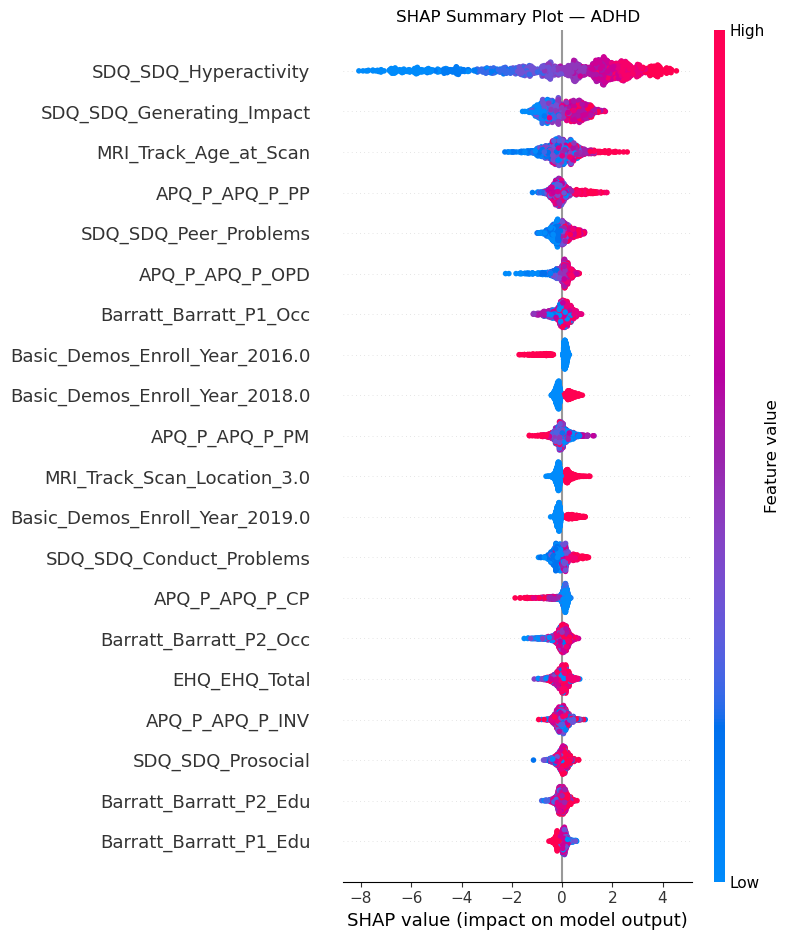

In [ ]:
# STEP 7: SHAP ANALYSIS — ADHD

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# SHAP explainer

explainer_adhd = shap.TreeExplainer(final_lgbm_adhd)

shap_values_adhd = explainer_adhd.shap_values(X_processed)

# Handle SHAP version differences
if isinstance(shap_values_adhd, list):
    shap_matrix = shap_values_adhd[1]
else:
    shap_matrix = shap_values_adhd

# Mean absolute SHAP importance

shap_importance_adhd = pd.DataFrame({
    "Feature": X_processed.columns,
    "Mean_Abs_SHAP": np.abs(shap_matrix).mean(axis=0)
})

shap_importance_adhd = (
    shap_importance_adhd
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_adhd.head(20))


# SHAP summary plot

shap.summary_plot(
    shap_matrix,
    X_processed,
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot — ADHD")
plt.tight_layout()
plt.show()

In [ ]:
# SEX — LIGHTGBM 5-FOLD CROSS-VALIDATION

import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Target
y_sex = metadata["Sex_F"].astype(int)

print("Predictor shape:", X_processed.shape)
print("\nSex distribution:")
print(y_sex.value_counts())
print("\nSex proportions:")
print(y_sex.value_counts(normalize=True).round(3))

# 5-fold stratified CV

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_processed, y_sex), start=1
):

    X_train = X_processed.iloc[train_idx]
    X_val = X_processed.iloc[val_idx]

    y_train = y_sex.iloc[train_idx]
    y_val = y_sex.iloc[val_idx]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC_AUC": roc_auc_score(y_val, y_prob)
    })


# Results

sex_cv_results = pd.DataFrame(results)

display(sex_cv_results.round(3))

summary = pd.DataFrame({
    "Mean": sex_cv_results.drop(columns="Fold").mean(),
    "SD": sex_cv_results.drop(columns="Fold").std()
})

display(summary.round(3))

Predictor shape: (1213, 38)

Sex distribution:
Sex_F
0    797
1    416
Name: count, dtype: int64

Sex proportions:
Sex_F
0    0.657
1    0.343
Name: proportion, dtype: float64


,Fold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.671,0.585,0.531,0.313,0.394,0.653
1,2,0.642,0.563,0.464,0.313,0.374,0.620
2,3,0.638,0.560,0.464,0.310,0.371,0.597
3,4,0.624,0.544,0.429,0.289,0.345,0.636
4,5,0.620,0.529,0.408,0.241,0.303,0.566


,Mean,SD
Accuracy,0.639,0.020
Balanced_Accuracy,0.556,0.021
Precision,0.459,0.047
Recall,0.293,0.031
F1,0.358,0.035
ROC_AUC,0.614,0.034


Confusion Matrix
[[653 144]
 [294 122]]


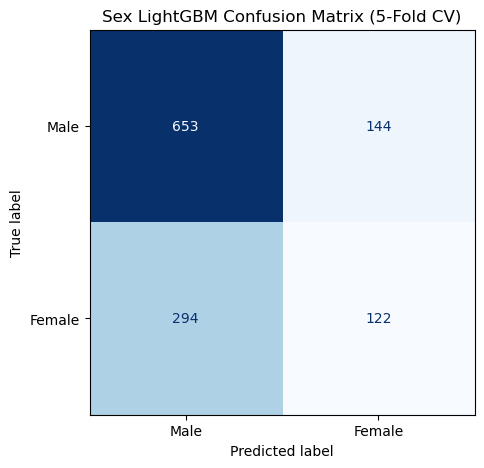

In [ ]:
# STEP X: SEX CONFUSION MATRIX

from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Same LightGBM model used in cross-validation
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

# Cross-validated predictions
y_pred = cross_val_predict(
    estimator=model,
    X=X_lgbm,
    y=y_sex,
    cv=cv,
    method="predict"
)

# Confusion matrix
cm = confusion_matrix(y_sex, y_pred)

print("Confusion Matrix")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Male", "Female"]
)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Sex LightGBM Confusion Matrix (5-Fold CV)")
plt.grid(False)
plt.show()

,Feature,Importance
0,MRI_Track_Age_at_Scan,2640.140958
1,EHQ_EHQ_Total,1948.824079
2,SDQ_SDQ_Hyperactivity,1510.663672
3,APQ_P_APQ_P_INV,1490.350701
4,APQ_P_APQ_P_ID,1426.026753
5,Barratt_Barratt_P2_Occ,1396.080257
6,SDQ_SDQ_Emotional_Problems,1367.168396
7,APQ_P_APQ_P_PM,1327.572784
8,APQ_P_APQ_P_OPD,1278.875717
9,SDQ_SDQ_Generating_Impact,1130.669259


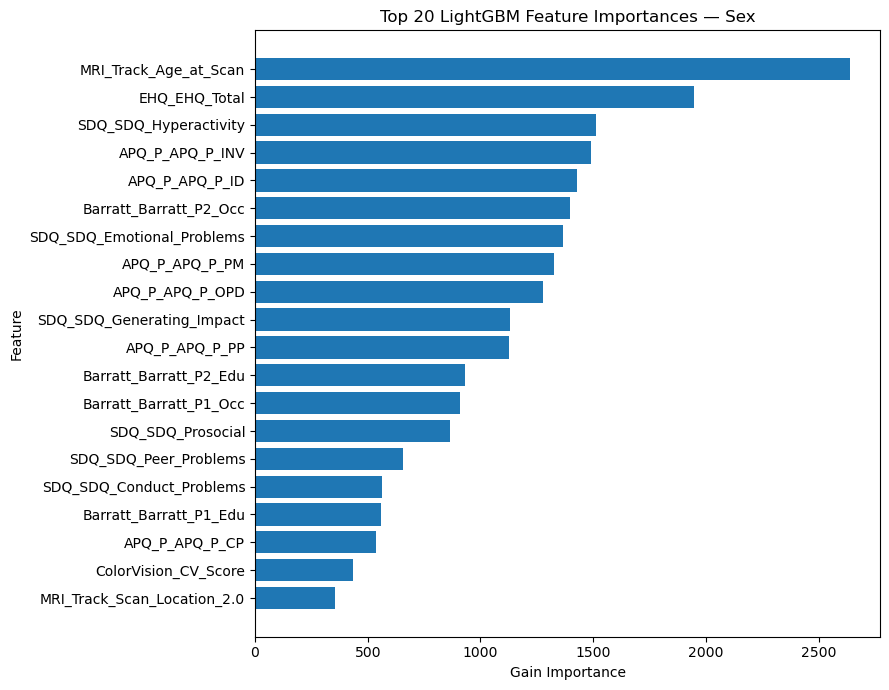

c:\anaconda3\envs\wids2025\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,Feature,Mean_Abs_SHAP
0,SDQ_SDQ_Hyperactivity,0.513277
1,SDQ_SDQ_Emotional_Problems,0.476902
2,MRI_Track_Age_at_Scan,0.415762
3,EHQ_EHQ_Total,0.334131
4,SDQ_SDQ_Prosocial,0.322912
5,Barratt_Barratt_P2_Occ,0.317594
6,APQ_P_APQ_P_INV,0.313155
7,APQ_P_APQ_P_ID,0.298083
8,APQ_P_APQ_P_OPD,0.243849
9,SDQ_SDQ_Generating_Impact,0.238020


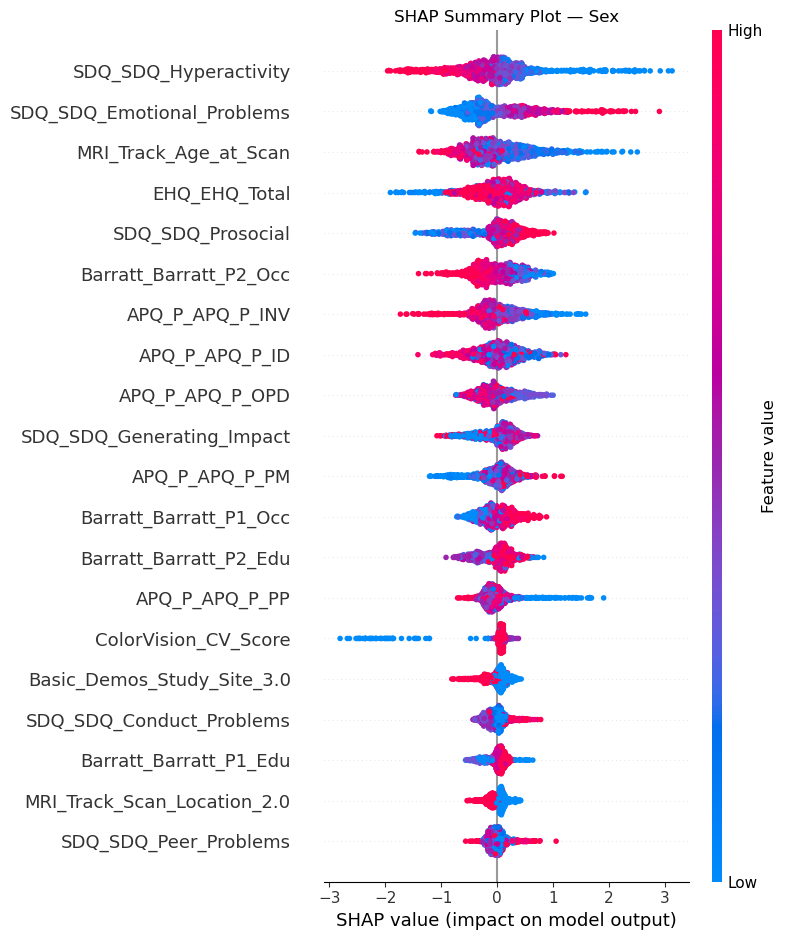

In [ ]:
# FINAL SEX LIGHTGBM + FEATURE IMPORTANCE + SHAP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMClassifier

# 1. Fit final model on full dataset

final_lgbm_sex = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

final_lgbm_sex.fit(X_processed, y_sex)


# 2. LightGBM gain importance

importance_sex = pd.DataFrame({
    "Feature": X_processed.columns,
    "Importance": final_lgbm_sex.booster_.feature_importance(
        importance_type="gain"
    )
})

importance_sex = (
    importance_sex
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_sex.head(20))


# Plot top 20
top20 = importance_sex.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Feature Importances — Sex")

plt.tight_layout()
plt.show()

# 3. SHAP

explainer_sex = shap.TreeExplainer(final_lgbm_sex)

shap_values_sex = explainer_sex.shap_values(X_processed)

# Handle SHAP version differences
if isinstance(shap_values_sex, list):
    shap_matrix_sex = shap_values_sex[1]
else:
    shap_matrix_sex = shap_values_sex

# 4. Mean absolute SHAP

shap_importance_sex = pd.DataFrame({
    "Feature": X_processed.columns,
    "Mean_Abs_SHAP": np.abs(shap_matrix_sex).mean(axis=0)
})

shap_importance_sex = (
    shap_importance_sex
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_sex.head(20))


# 5. SHAP summary plot

shap.summary_plot(
    shap_matrix_sex,
    X_processed,
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot — Sex")
plt.tight_layout()
plt.show()

ADHD: ROC-AUC 0.810 ± 0.028 → reasonably good discrimination.
Sex: ROC-AUC 0.614 ± 0.034 → weak/modest discrimination.

In [ ]:
# LOGISTIC REGRESSION — ADHD
# STEP 1: BOX-TIDWELL TEST

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


# ADHD target
y_adhd = metadata["ADHD_Outcome"].astype(int)

# Numerical variables

num_vars = [
    'EHQ_EHQ_Total',
    'ColorVision_CV_Score',

    'APQ_P_APQ_P_CP',
    'APQ_P_APQ_P_ID',
    'APQ_P_APQ_P_INV',
    'APQ_P_APQ_P_OPD',
    'APQ_P_APQ_P_PM',
    'APQ_P_APQ_P_PP',

    'SDQ_SDQ_Conduct_Problems',
    'SDQ_SDQ_Emotional_Problems',
    'SDQ_SDQ_Generating_Impact',
    'SDQ_SDQ_Hyperactivity',
    'SDQ_SDQ_Peer_Problems',
    'SDQ_SDQ_Prosocial',

    'MRI_Track_Age_at_Scan',

    # Barratt variables treated as numerical/ordinal
    'Barratt_Barratt_P1_Edu',
    'Barratt_Barratt_P1_Occ',
    'Barratt_Barratt_P2_Edu',
    'Barratt_Barratt_P2_Occ'
]


# Run Box-Tidwell separately for each numerical predictor

bt_results = []

for var in num_vars:

    x = X_imp[var].astype(float).copy()

    # Box-Tidwell requires positive values
    # Shift only when zero/negative values exist
    if x.min() <= 0:
        x_positive = x - x.min() + 1
    else:
        x_positive = x.copy()

    # Interaction: X * ln(X)
    x_log = x_positive * np.log(x_positive)

    # Model contains original X + Box-Tidwell interaction
    X_bt = pd.DataFrame({
        var: x,
        f"{var}_BT": x_log
    })

    X_bt = sm.add_constant(X_bt)

    try:

        model = sm.Logit(
            y_adhd,
            X_bt
        ).fit(
            disp=False,
            maxiter=500
        )

        bt_results.append({
            "Variable": var,
            "BT_Coefficient": model.params[f"{var}_BT"],
            "BT_P_value": model.pvalues[f"{var}_BT"]
        })

    except Exception as e:

        bt_results.append({
            "Variable": var,
            "BT_Coefficient": np.nan,
            "BT_P_value": np.nan
        })

        print(f"Problem with {var}: {e}")


# Results
bt_results = pd.DataFrame(bt_results)

# Multiple-testing correction
valid = bt_results["BT_P_value"].notna()

bt_results.loc[valid, "Adjusted_P"] = multipletests(
    bt_results.loc[valid, "BT_P_value"],
    method="fdr_bh"
)[1]


bt_results["Linear_Logit"] = np.where(
    bt_results["Adjusted_P"] < 0.05,
    "Evidence of non-linearity",
    "No evidence of non-linearity"
)

bt_results = bt_results.sort_values(
    "Adjusted_P"
).reset_index(drop=True)

display(bt_results.round(4))

,Variable,BT_Coefficient,BT_P_value,Adjusted_P,Linear_Logit
0,SDQ_SDQ_Generating_Impact,-0.2308,0.0056,0.0529,No evidence of non-linearity
1,SDQ_SDQ_Hyperactivity,-0.3826,0.0033,0.0529,No evidence of non-linearity
2,EHQ_EHQ_Total,0.0034,0.3843,0.6637,No evidence of non-linearity
3,ColorVision_CV_Score,-0.1488,0.3306,0.6637,No evidence of non-linearity
4,SDQ_SDQ_Peer_Problems,-0.1546,0.1489,0.6637,No evidence of non-linearity
5,SDQ_SDQ_Emotional_Problems,-0.1566,0.1135,0.6637,No evidence of non-linearity
6,APQ_P_APQ_P_PP,0.2399,0.3686,0.6637,No evidence of non-linearity
7,APQ_P_APQ_P_OPD,-0.1384,0.3165,0.6637,No evidence of non-linearity
8,SDQ_SDQ_Prosocial,-0.1929,0.2988,0.6637,No evidence of non-linearity
9,Barratt_Barratt_P2_Edu,-0.0910,0.2997,0.6637,No evidence of non-linearity


In [ ]:
# ADHD LOGISTIC REGRESSION

import statsmodels.api as sm
import numpy as np
import pandas as pd

# Target
y_adhd = target["ADHD_Outcome"].astype(int)

# Our final 38-predictor dataset
X_logit = X_processed.copy().astype(float)

# Add intercept
X_logit_const = sm.add_constant(X_logit)

print("Observations:", X_logit.shape[0])
print("Predictors:", X_logit.shape[1])
print("Parameters including intercept:", X_logit_const.shape[1])

# Fit model

logit_model = sm.Logit(
    y_adhd,
    X_logit_const
)

logit_result = logit_model.fit(
    method="newton",
    maxiter=500,
    disp=False
)

print("\nConverged:", logit_result.mle_retvals["converged"])
print("Iterations:", logit_result.mle_retvals["iterations"])


# OR, CI and p-values

coef = logit_result.params
ci = logit_result.conf_int()

logit_results = pd.DataFrame({
    "Variable": coef.index,
    "Coefficient": coef.values,
    "SE": logit_result.bse.values,
    "Odds_Ratio": np.exp(coef.values),
    "CI_Lower": np.exp(ci[0].values),
    "CI_Upper": np.exp(ci[1].values),
    "P_value": logit_result.pvalues.values
})

logit_results = logit_results.sort_values(
    "P_value"
).reset_index(drop=True)

display(logit_results.round(4))

Observations: 1213
Predictors: 38
Parameters including intercept: 39

Converged: True
Iterations: 5


,Variable,Coefficient,SE,Odds_Ratio,CI_Lower,CI_Upper,P_value
0,Basic_Demos_Study_Site_3.0,-0.2480,0.1744,0.7804,0.5544,1.0983,0.1550
1,PreInt_Demos_Fam_Child_Race_2.0,-0.3886,0.2784,0.6780,0.3928,1.1701,0.1628
2,Basic_Demos_Enroll_Year_2016.0,-0.6214,0.4477,0.5372,0.2234,1.2919,0.1652
3,PreInt_Demos_Fam_Child_Race_9.0,0.7920,0.5712,2.2077,0.7207,6.7633,0.1656
4,Barratt_Barratt_P1_Occ,-0.0057,0.0043,0.9943,0.9860,1.0027,0.1857
5,MRI_Track_Scan_Location_2.0,-0.4627,0.3562,0.6296,0.3132,1.2656,0.1940
6,MRI_Track_Scan_Location_3.0,-0.5138,0.4036,0.5982,0.2712,1.3195,0.2030
7,SDQ_SDQ_Conduct_Problems,0.0519,0.0420,1.0532,0.9700,1.1436,0.2169
8,PreInt_Demos_Fam_Child_Ethnicity_1.0,0.2294,0.2062,1.2578,0.8396,1.8844,0.2660
9,SDQ_SDQ_Hyperactivity,-0.0322,0.0293,0.9683,0.9143,1.0254,0.2706


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# Numerical predictors only
X_vif = X_processed[num_vars].copy().astype(float)

X_vif = sm.add_constant(X_vif)

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Remove intercept
vif_results = vif_results[
    vif_results["Variable"] != "const"
].sort_values("VIF", ascending=False)

display(vif_results.round(2))

,Variable,VIF
11,SDQ_SDQ_Generating_Impact,2.12
15,MRI_Track_Age_at_Scan,2.05
7,APQ_P_APQ_P_PM,1.90
9,SDQ_SDQ_Conduct_Problems,1.77
18,Barratt_Barratt_P2_Edu,1.72
5,APQ_P_APQ_P_INV,1.69
12,SDQ_SDQ_Hyperactivity,1.67
8,APQ_P_APQ_P_PP,1.58
19,Barratt_Barratt_P2_Occ,1.57
13,SDQ_SDQ_Peer_Problems,1.57


In [26]:
#Logistic regression performance
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import numpy as np


X_lr = X_processed.copy()
y_lr = target["ADHD_Outcome"].astype(int)


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []


for fold, (train_idx, test_idx) in enumerate(
    skf.split(X_lr, y_lr), start=1
):

    X_train = X_lr.iloc[train_idx]
    X_test = X_lr.iloc[test_idx]

    y_train = y_lr.iloc[train_idx]
    y_test = y_lr.iloc[test_idx]

    model = LogisticRegression(
    penalty=None,
    max_iter=5000
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })


cv_results = pd.DataFrame(cv_results)

display(cv_results.round(3))


summary = pd.DataFrame({
    "Mean": cv_results.drop(columns="Fold").mean(),
    "SD": cv_results.drop(columns="Fold").std()
})

display(summary.round(3))

c:\anaconda3\envs\wids2025\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\anaconda3\envs\wids2025\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\anaconda3\envs\wids2025\Lib\site-packages\sklearn\lin

,Fold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.667,0.485,0.681,0.970,0.800,0.513
1,2,0.675,0.501,0.684,0.976,0.804,0.430
2,3,0.691,0.516,0.690,0.994,0.815,0.532
3,4,0.632,0.468,0.671,0.910,0.772,0.425
4,5,0.674,0.495,0.684,0.976,0.804,0.527


,Mean,SD
Accuracy,0.668,0.022
Balanced_Accuracy,0.493,0.018
Precision,0.682,0.007
Recall,0.965,0.032
F1,0.799,0.016
ROC_AUC,0.485,0.053


In [ ]:
# OVERALL LOGISTIC REGRESSION MODEL TEST

print("Log-Likelihood:", round(logit_result.llf, 3))
print("Null Log-Likelihood:", round(logit_result.llnull, 3))

print("\nLikelihood Ratio Chi-square:",
      round(logit_result.llr, 3))

print("Degrees of freedom:",
      int(logit_result.df_model))

print("Likelihood Ratio p-value:",
      logit_result.llr_pvalue)

print("\nMcFadden Pseudo R²:",
      round(logit_result.prsquared, 4))

Log-Likelihood: -740.193
Null Log-Likelihood: -755.677

Likelihood Ratio Chi-square: 30.97
Degrees of freedom: 38
Likelihood Ratio p-value: 0.7836372816719764

McFadden Pseudo R²: 0.0205


The important results are:

Likelihood-ratio χ²(38) = 30.97, p = 0.784
The full logistic model is not significantly better than the intercept-only model.
So, taken together, these 38 predictors do not provide significant evidence for predicting ADHD under this logistic specification.
McFadden pseudo-R² = 0.0205
Only a very small improvement in model fit over the null model.

In [ ]:
# BOX-TIDWELL TEST — SEX

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

# Target
y_sex = target["Sex_F"].astype(int)

# Numerical predictors
num_vars = [
    'EHQ_EHQ_Total',
    'ColorVision_CV_Score',
    'APQ_P_APQ_P_CP',
    'APQ_P_APQ_P_ID',
    'APQ_P_APQ_P_INV',
    'APQ_P_APQ_P_OPD',
    'APQ_P_APQ_P_PM',
    'APQ_P_APQ_P_PP',
    'SDQ_SDQ_Conduct_Problems',
    'SDQ_SDQ_Emotional_Problems',
    'SDQ_SDQ_Generating_Impact',
    'SDQ_SDQ_Hyperactivity',
    'SDQ_SDQ_Peer_Problems',
    'SDQ_SDQ_Prosocial',
    'MRI_Track_Age_at_Scan',
    'Barratt_Barratt_P1_Edu',
    'Barratt_Barratt_P1_Occ',
    'Barratt_Barratt_P2_Edu',
    'Barratt_Barratt_P2_Occ'
]

bt_results = []

for var in num_vars:

    x = X_imp[var].astype(float).copy()

    # Shift variable so all values are > 0
    if x.min() <= 0:
        x = x - x.min() + 1

    x_log_x = x * np.log(x)

    X_bt = pd.DataFrame({
        var: x,
        f"{var}_log": x_log_x
    })

    X_bt = sm.add_constant(X_bt)

    model = sm.Logit(y_sex, X_bt).fit(disp=False)

    bt_results.append({
        "Variable": var,
        "BT_Coefficient": model.params[f"{var}_log"],
        "BT_P_value": model.pvalues[f"{var}_log"]
    })


bt_results = pd.DataFrame(bt_results)

# FDR correction for multiple testing
bt_results["Adjusted_P"] = multipletests(
    bt_results["BT_P_value"],
    method="fdr_bh"
)[1]

bt_results["Linear_Logit"] = np.where(
    bt_results["Adjusted_P"] < 0.05,
    "Evidence of non-linearity",
    "No evidence of non-linearity"
)

bt_results = bt_results.sort_values("Adjusted_P")

display(bt_results.round(4))

,Variable,BT_Coefficient,BT_P_value,Adjusted_P,Linear_Logit
0,EHQ_EHQ_Total,0.0080,0.0343,0.3841,No evidence of non-linearity
13,SDQ_SDQ_Prosocial,0.2742,0.0733,0.3841,No evidence of non-linearity
11,SDQ_SDQ_Hyperactivity,-0.1538,0.0509,0.3841,No evidence of non-linearity
9,SDQ_SDQ_Emotional_Problems,-0.1392,0.1213,0.3841,No evidence of non-linearity
12,SDQ_SDQ_Peer_Problems,-0.1662,0.0901,0.3841,No evidence of non-linearity
18,Barratt_Barratt_P2_Occ,-0.0211,0.1204,0.3841,No evidence of non-linearity
4,APQ_P_APQ_P_INV,-0.2224,0.1640,0.4452,No evidence of non-linearity
6,APQ_P_APQ_P_PM,-0.0685,0.2864,0.5956,No evidence of non-linearity
8,SDQ_SDQ_Conduct_Problems,-0.1068,0.2584,0.5956,No evidence of non-linearity
14,MRI_Track_Age_at_Scan,-0.1215,0.3135,0.5956,No evidence of non-linearity


In [ ]:
# SEX LOGISTIC REGRESSION

import statsmodels.api as sm
import numpy as np
import pandas as pd

# Target
y_sex = target["Sex_F"].astype(int)

# Same final 38 predictors
X_logit_sex = X_processed.copy().astype(float)

# Add intercept
X_logit_sex_const = sm.add_constant(X_logit_sex)

print("Observations:", X_logit_sex.shape[0])
print("Predictors:", X_logit_sex.shape[1])
print("Parameters including intercept:",
      X_logit_sex_const.shape[1])


# Fit logistic regression
sex_logit_model = sm.Logit(
    y_sex,
    X_logit_sex_const
)

sex_logit_result = sex_logit_model.fit(
    method="newton",
    maxiter=500,
    disp=False
)

print("\nConverged:",
      sex_logit_result.mle_retvals["converged"])

print("Iterations:",
      sex_logit_result.mle_retvals["iterations"])


# OR, CI and p-values

coef = sex_logit_result.params
ci = sex_logit_result.conf_int()

sex_logit_results = pd.DataFrame({
    "Variable": coef.index,
    "Coefficient": coef.values,
    "SE": sex_logit_result.bse.values,
    "Odds_Ratio": np.exp(coef.values),
    "CI_Lower": np.exp(ci[0].values),
    "CI_Upper": np.exp(ci[1].values),
    "P_value": sex_logit_result.pvalues.values
})

sex_logit_results = (
    sex_logit_results
    .sort_values("P_value")
    .reset_index(drop=True)
)

display(sex_logit_results.round(4))

Observations: 1213
Predictors: 38
Parameters including intercept: 39

Converged: True
Iterations: 5


,Variable,Coefficient,SE,Odds_Ratio,CI_Lower,CI_Upper,P_value
0,SDQ_SDQ_Hyperactivity,-0.0792,0.0290,0.9238,0.8728,0.9779,0.0063
1,MRI_Track_Age_at_Scan,-0.0703,0.0313,0.9321,0.8767,0.9911,0.0247
2,SDQ_SDQ_Prosocial,-0.0756,0.0363,0.9272,0.8635,0.9956,0.0375
3,APQ_P_APQ_P_PM,0.0326,0.0168,1.0331,0.9997,1.0677,0.0520
4,Basic_Demos_Enroll_Year_2016.0,-0.7511,0.3958,0.4719,0.2172,1.0250,0.0577
5,APQ_P_APQ_P_INV,0.0312,0.0168,1.0317,0.9982,1.0663,0.0636
6,Basic_Demos_Enroll_Year_2018.0,-0.9580,0.5239,0.3837,0.1374,1.0713,0.0675
7,Basic_Demos_Study_Site_3.0,0.3070,0.1707,1.3594,0.9729,1.8994,0.0720
8,APQ_P_APQ_P_PP,-0.0383,0.0258,0.9624,0.9149,1.0124,0.1380
9,Basic_Demos_Enroll_Year_2019.0,-0.7249,0.5299,0.4844,0.1714,1.3684,0.1713


We actually don't need to calculate VIF again. The predictor matrix is exactly the same X_processed used for ADHD, and VIF depends only on the predictors—not the outcome. We already established that the maximum numerical VIF was 2.12.

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

X_lr = X_processed.copy()
y_lr = target["Sex_F"].astype(int)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

sex_cv_results = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X_lr, y_lr), start=1
):

    X_train = X_lr.iloc[train_idx]
    X_test = X_lr.iloc[test_idx]

    y_train = y_lr.iloc[train_idx]
    y_test = y_lr.iloc[test_idx]

    model = LogisticRegression(
        penalty=None,
        max_iter=5000
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    sex_cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

sex_cv_results = pd.DataFrame(sex_cv_results)

display(sex_cv_results.round(3))

sex_cv_summary = pd.DataFrame({
    "Mean": sex_cv_results.drop(columns="Fold").mean(),
    "SD": sex_cv_results.drop(columns="Fold").std()
})

display(sex_cv_summary.round(3))

c:\anaconda3\envs\wids2025\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\anaconda3\envs\wids2025\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\anaconda3\envs\wids2025\Lib\site-packages\sklearn\lin

,Fold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.634,0.498,0.333,0.060,0.101,0.503
1,2,0.621,0.495,0.320,0.096,0.148,0.449
2,3,0.646,0.499,0.333,0.036,0.065,0.570
3,4,0.620,0.475,0.091,0.012,0.021,0.515
4,5,0.653,0.514,0.462,0.072,0.125,0.551


,Mean,SD
Accuracy,0.635,0.015
Balanced_Accuracy,0.496,0.014
Precision,0.308,0.134
Recall,0.055,0.033
F1,0.092,0.050
ROC_AUC,0.518,0.047


In [ ]:
# OVERALL SEX LOGISTIC REGRESSION MODEL TEST

print("Log-Likelihood:",
      round(sex_logit_result.llf, 3))

print("Null Log-Likelihood:",
      round(sex_logit_result.llnull, 3))

print("\nLikelihood Ratio Chi-square:",
      round(sex_logit_result.llr, 3))

print("Degrees of freedom:",
      int(sex_logit_result.df_model))

print("Likelihood Ratio p-value:",
      sex_logit_result.llr_pvalue)

print("\nMcFadden Pseudo R²:",
      round(sex_logit_result.prsquared, 4))

Log-Likelihood: -761.273
Null Log-Likelihood: -779.927

Likelihood Ratio Chi-square: 37.309
Degrees of freedom: 38
Likelihood Ratio p-value: 0.501215398691812

McFadden Pseudo R²: 0.0239


So, as a whole, the 38-predictor logistic model does not significantly improve over the intercept-only model for predicting sex. It also explains very little variation.

So there is a useful distinction in our analysis: some individual predictors were statistically significant for Sex, but the overall model was not significant and had essentially no useful predictive discrimination.

At this point, the clinical/sociodemographic logisti